In [319]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

,Discharge1974-2002,Discharge2008-2023
Date,,
1983,353.044,NaN
1993,336.292,NaN
1994,332.691,NaN
1996,340.067,NaN
2015,NaN,337.660
2019,NaN,301.376
2021,NaN,342.440


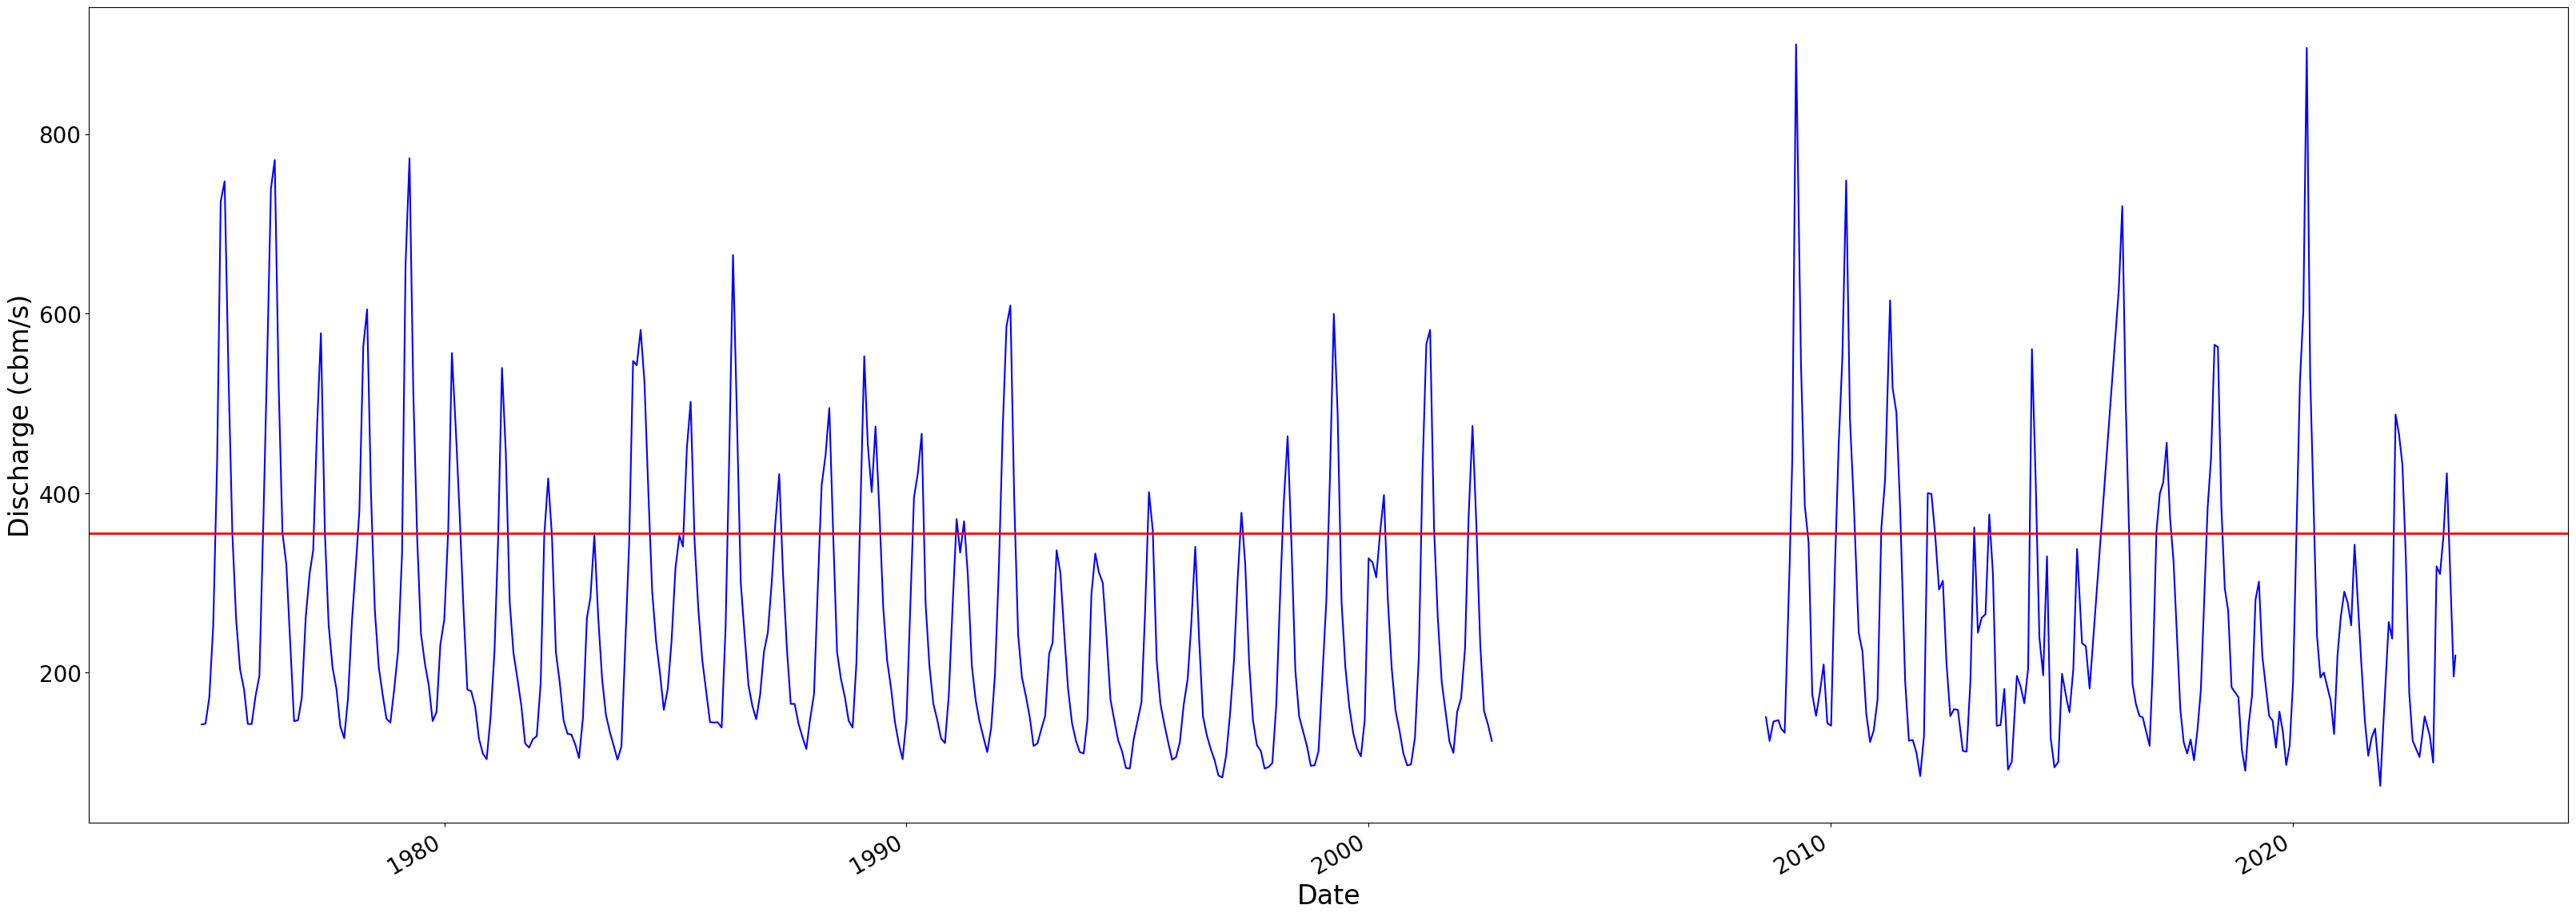

In [320]:
data1 = pd.read_csv("../BEP/data/Discharge data Mohembo 1974-2002.txt", index_col=0, sep="\t", parse_dates=True, 
                    date_format="%Y-%m", comment='#', header=None, names=["Date", "Discharge1974-2002"])
data2 = pd.read_csv("../BEP/data/Discharge data Mohembo 2008-2023.txt", sep=",", comment='#', 
                    header=None, names=["YYYY", "MM", "DD", "Discharge2008-2023", "Error"])
data2["Date"] = pd.to_datetime(dict(year=data2.iloc[:,0], month=data2.iloc[:,1], day=data2.iloc[:,2]))
data2 = data2.drop(columns=["YYYY", "MM", "DD", "Error"])
data2 = data2.set_index("Date")
data1 = data1[data1["Discharge1974-2002"] >= 0]
combined = pd.concat([data1, data2])

fig, ax = plt.subplots(figsize=(40, 15))
combined.plot(ax=ax, color='blue', legend=False)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.set_xlabel("Date", fontsize=24)
ax.set_ylabel("Discharge (cbm/s)", fontsize=24)
plt.axhline(y=355, color='red', linewidth=2);

yearly_max = combined.groupby(combined.index.year).max()
filtered_years1 = yearly_max[(yearly_max["Discharge1974-2002"] > 180) & (yearly_max["Discharge1974-2002"] < 355)]
filtered_years2 = yearly_max[(yearly_max["Discharge2008-2023"] > 160) & (yearly_max["Discharge2008-2023"] < 355)]
filtered_years = pd.concat([filtered_years1, filtered_years2])
filtered_years

In [356]:
combined1 = combined
combined1["Discharge"] = combined1["Discharge1974-2002"].combine_first(combined1["Discharge2008-2023"])
combined1 = combined1.drop(columns=["Discharge1974-2002", "Discharge2008-2023"])
seconds = combined1.index.days_in_month * 24 * 3600
yearly_sum = (combined1["Discharge"] * seconds).resample("YE").sum() / 1e6
count = combined1.groupby(combined1.index.year).size()
yearly_sum = yearly_sum.to_frame(name="Volume")
yearly_sum["N"] = yearly_sum.index.year.map(count)
yearly_sum = yearly_sum[yearly_sum["N"].notna() & (yearly_sum["N"] == 12)]
yearly_sum

,Volume,N
Date,,
1975-12-31,10894.337395,12.0
1976-12-31,11871.504806,12.0
1977-12-31,8924.653094,12.0
1978-12-31,9580.605869,12.0
1979-12-31,10549.252426,12.0
1980-12-31,8302.408157,12.0
1981-12-31,7686.635616,12.0
1982-12-31,6529.277808,12.0
1984-12-31,11141.500061,12.0
